# 01. Matplotlib vs Plotly 기능 비교

농업 데이터를 예로 들어 **정적 시각화(Matplotlib)** 와 **인터랙티브 시각화(Plotly)** 의 차이점을 비교합니다.

| 항목 | Matplotlib | Plotly |
|------|------------|--------|
| 결과물 | 정적 이미지 | 인터랙티브 차트 |
| 상호작용 | 제한적 | 줌, 호버, 범례 토글 등 |
| 대시보드 | 단독 사용이 많음 | Dash / Streamlit과 잘 맞음 |
| 학습 곡선 | 낮음~중간 | 중간 |
| 출력 형태 | PNG, PDF, SVG | HTML, JSON, 정적 이미지도 가능 |

## 0. 라이브러리 설치 (필요 시)

아래 셀은 한 번만 실행하면 됩니다.

In [1]:
%pip install matplotlib plotly pandas numpy -q

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. 공통 데이터 준비

동일 데이터로 두 라이브러리를 비교하기 위해 가상 농업 데이터를 만듭니다.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)

months = ["1월", "2월", "3월", "4월", "5월", "6월",
          "7월", "8월", "9월", "10월", "11월", "12월"]

df = pd.DataFrame({
    "월": months,
    "기온_C": [1.2, 3.5, 8.1, 14.0, 19.2, 23.5, 26.8, 27.1, 22.4, 15.6, 8.9, 2.8],
    "강수량_mm": [28, 35, 55, 80, 110, 160, 280, 260, 150, 60, 45, 30],
    "수확량_톤": [12, 15, 22, 35, 48, 62, 70, 68, 55, 40, 25, 18],
})

regions = pd.DataFrame({
    "지역": ["경기", "충남", "전북", "경북", "제주"],
    "평균수확량": [42, 55, 61, 48, 38],
    "평균기온": [12.5, 13.1, 13.8, 12.9, 16.2],
})

df.head()

,월,기온_C,강수량_mm,수확량_톤
0,1월,1.2,28,12
1,2월,3.5,35,15
2,3월,8.1,55,22
3,4월,14.0,80,35
4,5월,19.2,110,48


---
## 2. 선 그래프 (Line Chart)

**비교 포인트**
- Matplotlib: 코드로 축/범례/스타일을 직접 지정 → 보고서·논문용 정적 그림에 강함
- Plotly: 마우스 오버 시 값 표시, 줌/팬 가능 → 탐색·대시보드에 강함

### 2-1. Matplotlib

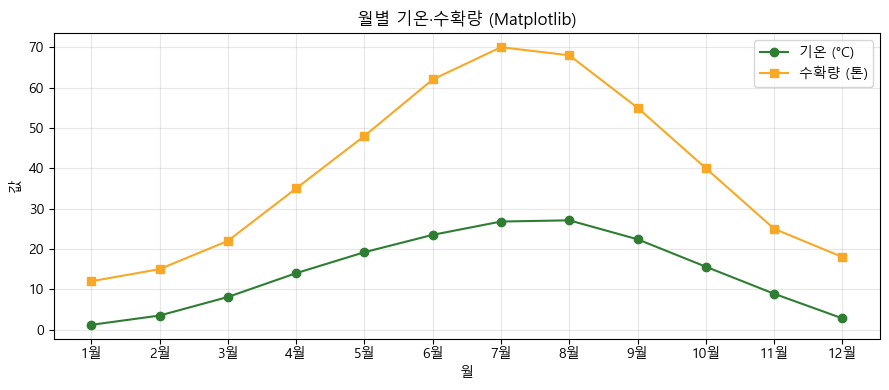

In [2]:
import matplotlib.pyplot as plt

# 한글 폰트 (Windows 기본)
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df["월"], df["기온_C"], marker="o", label="기온 (°C)", color="#2E7D32")
ax.plot(df["월"], df["수확량_톤"], marker="s", label="수확량 (톤)", color="#F9A825")
ax.set_title("월별 기온·수확량 (Matplotlib)")
ax.set_xlabel("월")
ax.set_ylabel("값")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 2-2. Plotly

In [3]:
import plotly.express as px

fig = px.line(
    df,
    x="월",
    y=["기온_C", "수확량_톤"],
    markers=True,
    title="월별 기온·수확량 (Plotly)",
    labels={"value": "값", "variable": "지표"},
    color_discrete_sequence=["#2E7D32", "#F9A825"],
)
fig.update_layout(hovermode="x unified")
fig.show()

---
## 3. 막대 그래프 (Bar Chart)

**비교 포인트**
- Matplotlib: `ax.bar`로 세밀한 스타일 제어
- Plotly: 호버 툴팁·애니메이션·색상 매핑이 기본 제공

### 3-1. Matplotlib

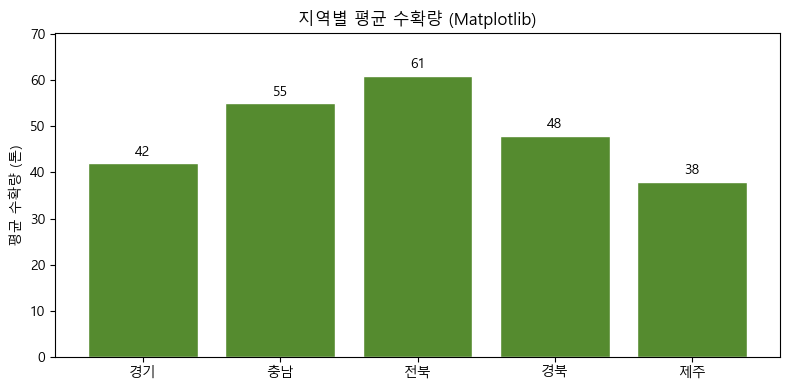

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(regions["지역"], regions["평균수확량"], color="#558B2F", edgecolor="white")
ax.bar_label(bars, padding=3)
ax.set_title("지역별 평균 수확량 (Matplotlib)")
ax.set_ylabel("평균 수확량 (톤)")
ax.set_ylim(0, max(regions["평균수확량"]) * 1.15)
plt.tight_layout()
plt.show()

### 3-2. Plotly

In [5]:
fig = px.bar(
    regions,
    x="지역",
    y="평균수확량",
    text="평균수확량",
    color="평균수확량",
    color_continuous_scale="YlGn",
    title="지역별 평균 수확량 (Plotly)",
)
fig.update_traces(textposition="outside")
fig.update_layout(yaxis_title="평균 수확량 (톤)")
fig.show()

---
## 4. 산점도 (Scatter)

**비교 포인트**
- Matplotlib: 관계 확인용 정적 산점도
- Plotly: 포인트 호버로 세부 값 확인, 범례/선택 도구 사용 가능

### 4-1. Matplotlib

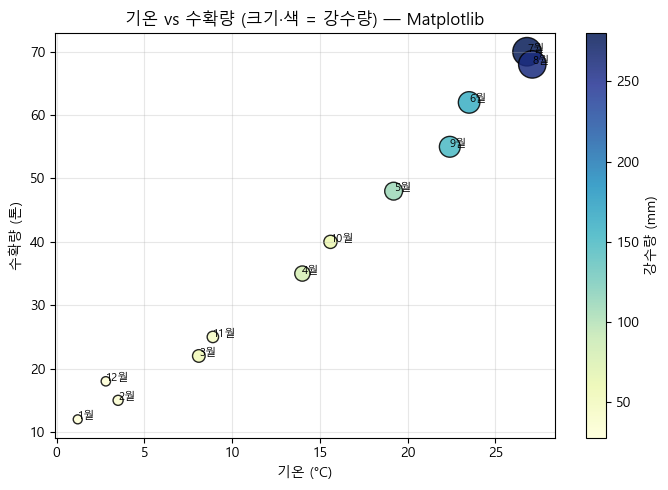

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(
    df["기온_C"],
    df["수확량_톤"],
    c=df["강수량_mm"],
    s=df["강수량_mm"] * 1.5,
    cmap="YlGnBu",
    alpha=0.85,
    edgecolors="k",
)
for i, m in enumerate(df["월"]):
    ax.annotate(m, (df["기온_C"].iloc[i], df["수확량_톤"].iloc[i]), fontsize=8)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("강수량 (mm)")
ax.set_title("기온 vs 수확량 (크기·색 = 강수량) — Matplotlib")
ax.set_xlabel("기온 (°C)")
ax.set_ylabel("수확량 (톤)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4-2. Plotly

In [7]:
fig = px.scatter(
    df,
    x="기온_C",
    y="수확량_톤",
    size="강수량_mm",
    color="강수량_mm",
    hover_name="월",
    color_continuous_scale="YlGnBu",
    title="기온 vs 수확량 (크기·색 = 강수량) — Plotly",
    labels={"기온_C": "기온 (°C)", "수확량_톤": "수확량 (톤)", "강수량_mm": "강수량 (mm)"},
)
fig.show()

---
## 5. 서브플롯 / 다중 차트

**비교 포인트**
- Matplotlib: `plt.subplots`로 격자 배치가 직관적
- Plotly: `make_subplots`로 인터랙티브 다중 패널 구성

### 5-1. Matplotlib

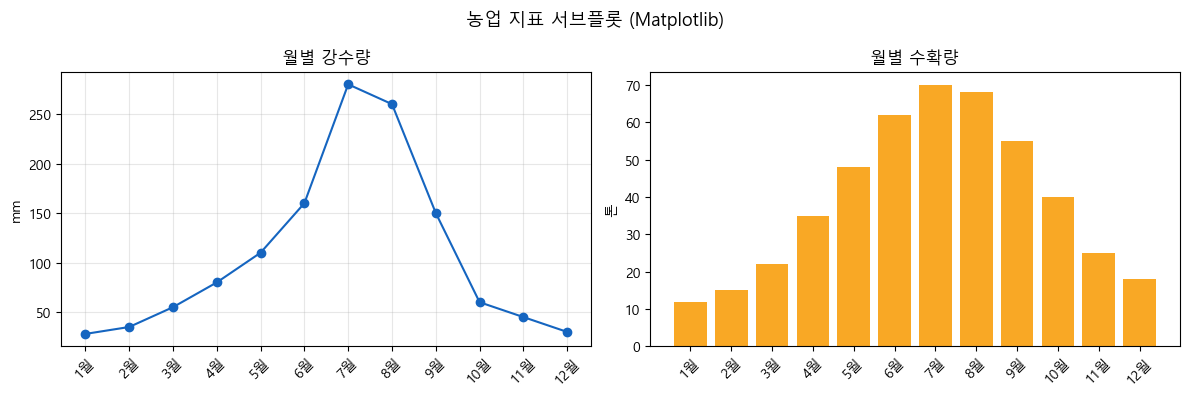

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(df["월"], df["강수량_mm"], color="#1565C0", marker="o")
axes[0].set_title("월별 강수량")
axes[0].set_ylabel("mm")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].bar(df["월"], df["수확량_톤"], color="#F9A825")
axes[1].set_title("월별 수확량")
axes[1].set_ylabel("톤")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("농업 지표 서브플롯 (Matplotlib)", fontsize=13)
plt.tight_layout()
plt.show()

### 5-2. Plotly

In [9]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("월별 강수량", "월별 수확량"),
)

fig.add_trace(
    go.Scatter(x=df["월"], y=df["강수량_mm"], mode="lines+markers",
               name="강수량", line=dict(color="#1565C0")),
    row=1, col=1,
)
fig.add_trace(
    go.Bar(x=df["월"], y=df["수확량_톤"], name="수확량",
           marker_color="#F9A825"),
    row=1, col=2,
)

fig.update_layout(title_text="농업 지표 서브플롯 (Plotly)", showlegend=False)
fig.update_yaxes(title_text="mm", row=1, col=1)
fig.update_yaxes(title_text="톤", row=1, col=2)
fig.show()

---
## 6. Plotly만의 강점: 인터랙티브 기능

Matplotlib로는 구현이 번거로운 **호버·드롭다운·범위 슬라이더** 등을 Plotly는 비교적 쉽게 제공합니다.

In [10]:
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df["월"], y=df["기온_C"],
    mode="lines+markers", name="기온",
    line=dict(color="#2E7D32"),
))
fig.add_trace(go.Scatter(
    x=df["월"], y=df["강수량_mm"],
    mode="lines+markers", name="강수량",
    line=dict(color="#1565C0"),
    visible=False,
))
fig.add_trace(go.Scatter(
    x=df["월"], y=df["수확량_톤"],
    mode="lines+markers", name="수확량",
    line=dict(color="#F9A825"),
    visible=False,
))

fig.update_layout(
    title="지표 전환 드롭다운 (Plotly)",
    updatemenus=[{
        "buttons": [
            {"label": "기온", "method": "update",
             "args": [{"visible": [True, False, False]}, {"yaxis": {"title": "°C"}}]},
            {"label": "강수량", "method": "update",
             "args": [{"visible": [False, True, False]}, {"yaxis": {"title": "mm"}}]},
            {"label": "수확량", "method": "update",
             "args": [{"visible": [False, False, True]}, {"yaxis": {"title": "톤"}}]},
        ],
        "direction": "down",
        "showactive": True,
        "x": 1.0,
        "xanchor": "right",
        "y": 1.15,
    }],
)
fig.show()

---
## 7. Matplotlib만의 강점: 세밀한 정적 커스터마이징

논문·리포트용으로 **축 눈금, 주석, 저장 해상도**를 세밀하게 맞추기 쉽습니다.

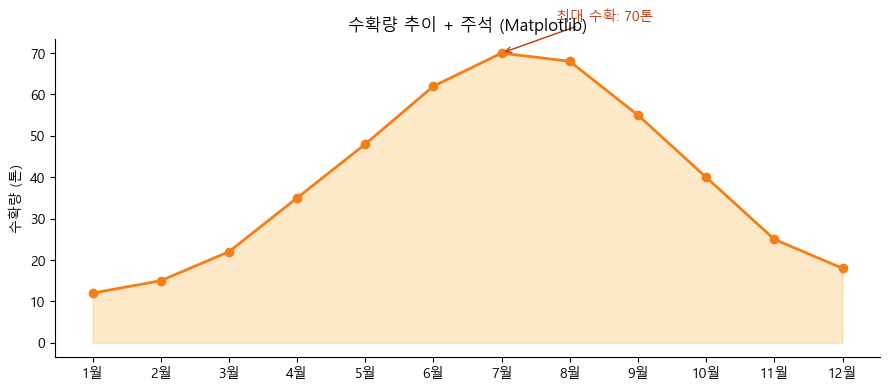

In [11]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.fill_between(df["월"], df["수확량_톤"], alpha=0.25, color="#F9A825")
ax.plot(df["월"], df["수확량_톤"], color="#F57F17", marker="o", linewidth=2)

peak_idx = df["수확량_톤"].idxmax()
ax.annotate(
    f"최대 수확: {df.loc[peak_idx, '수확량_톤']}톤",
    xy=(df.loc[peak_idx, "월"], df.loc[peak_idx, "수확량_톤"]),
    xytext=(peak_idx + 0.8, df.loc[peak_idx, "수확량_톤"] + 8),
    arrowprops=dict(arrowstyle="->", color="#BF360C"),
    fontsize=10,
    color="#BF360C",
)

ax.set_title("수확량 추이 + 주석 (Matplotlib)")
ax.set_ylabel("수확량 (톤)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()

# 파일로 저장 예시 (원하면 주석 해제)
# fig.savefig("harvest_trend.png", dpi=200, bbox_inches="tight")
plt.show()

---
## 8. 정리: 언제 무엇을 쓸까?

| 상황 | 추천 |
|------|------|
| 보고서·논문용 정적 그림 | **Matplotlib** |
| 탐색적 분석, 호버로 값 확인 | **Plotly** |
| 웹 대시보드 (클릭·필터·줌) | **Plotly** (+ Dash/Streamlit) |
| 세밀한 레이아웃·주석·인쇄물 | **Matplotlib** |
| 빠른 프로토타입 (pandas 연동) | 둘 다 가능 (Plotly Express가 특히 간결) |

다음 단계에서는 이 프로젝트의 농업 대시보드에 **Plotly**를 중심으로 인터랙티브 차트를 구성하고, 필요 시 Matplotlib로 정적 리포트용 그림을 보완하는 구성을 권장합니다.